In [1]:
from nn_rns import rns_networks
from nn_rns import EoSTable
# from src.nn_rns.networks import rns_networks
# from src.nn_rns.networks import EoSTable
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib widget

##########################
# color and style settings
##########################
hue_tab = sns.color_palette("tab10")
sat_tab0 = sns.dark_palette(hue_tab[0], reverse=True, as_cmap=False, n_colors=4)
sat_tab1 = sns.dark_palette(hue_tab[1], reverse=True, as_cmap=False, n_colors=4)
sat_tab2 = sns.dark_palette(hue_tab[2], reverse=True, as_cmap=False, n_colors=4)
sat_tab3 = sns.dark_palette(hue_tab[3], reverse=True, as_cmap=False, n_colors=4)
sns.set_context("notebook", font_scale=1.25, rc={"lines.linewidth": 2.5})
##########################

# recommended assignment
static_color = "#222222"     # special baseline
kepler_color = sat_tab3[-1]  # strongest red

mid_colors = [
    sat_tab0[0], sat_tab0[1], sat_tab0[2], sat_tab0[3],  # 4 blues
    sat_tab1[1], sat_tab1[2], sat_tab1[3],               # 3 oranges
    sat_tab2[1], sat_tab2[2], sat_tab2[3],               # 3 greens
]

all_colors = [kepler_color] + mid_colors + [static_color]


# run for SLY EoS
nn_rns_sly = rns_networks()
sly_eos = EoSTable("./eos/sly.rns")

nn_rns_sly.rns_eval(sly_eos)

# run for DD2 EoS
nn_rns_dd2 = rns_networks()
dd2_eos = EoSTable("./eos/dd2.rns")
nn_rns_dd2.rns_eval(dd2_eos)

# run for SFHo EoS
nn_rns_sfho = rns_networks()
sfho_eos = EoSTable("./eos/sfho.rns")
nn_rns_sfho.rns_eval(sfho_eos)

/Users/zhenyu/miniforge3/lib/python3.12/site-packages/nn_rns/NN/nn.py:425: RuntimeWarning: nb of NN exceeds EOS table max; using linear extrapolation.
  p_arr = EoSTable.p_from_nb(self.nb_arr)


# 1. NN outputs

<div class="alert alert-block alert-info">
<b>Warning:</b> Data after the maximum mass may not be trustworthy due to the lack of training data.
</div>

### 1.1 SLy EoS

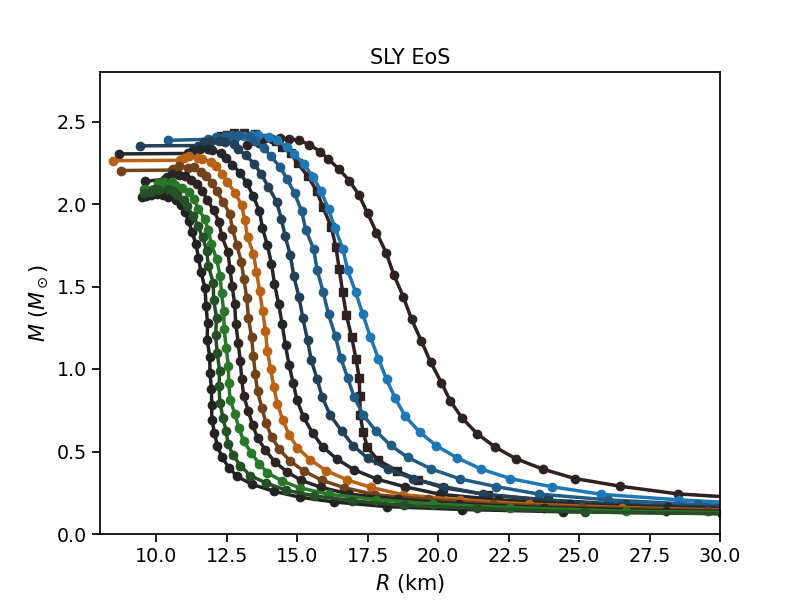

In [2]:
fig = plt.figure(figsize=(8, 6))
ax = plt.subplot(111)

# sly EoS
sly_static_star = nn_rns_sly.nn_rns_static
sly_kepler_star = nn_rns_sly.nn_rns_kepler
sly_rotate_star = nn_rns_sly.nn_rns_rotate

ax.plot(sly_static_star[:,2], sly_static_star[:,0], color=all_colors[11], marker="o", label="sly static")
ax.plot(sly_kepler_star[:,2], sly_kepler_star[:,0], color=all_colors[0], marker="s", label="sly kepler")

for i_ratio in range(sly_rotate_star.shape[0]):
    ax.plot(sly_rotate_star[i_ratio,:,2], sly_rotate_star[i_ratio,:,0], color=all_colors[i_ratio], marker="o")

ax.set_xlim(8, 30)
ax.set_ylim(0, 2.8)

ax.set_xlabel(r"$R$ (km)")
ax.set_ylabel(r"$M$ ($M_\odot$)")
ax.set_title("SLY EoS")

plt.show()

### 1.2 DD2 EoS

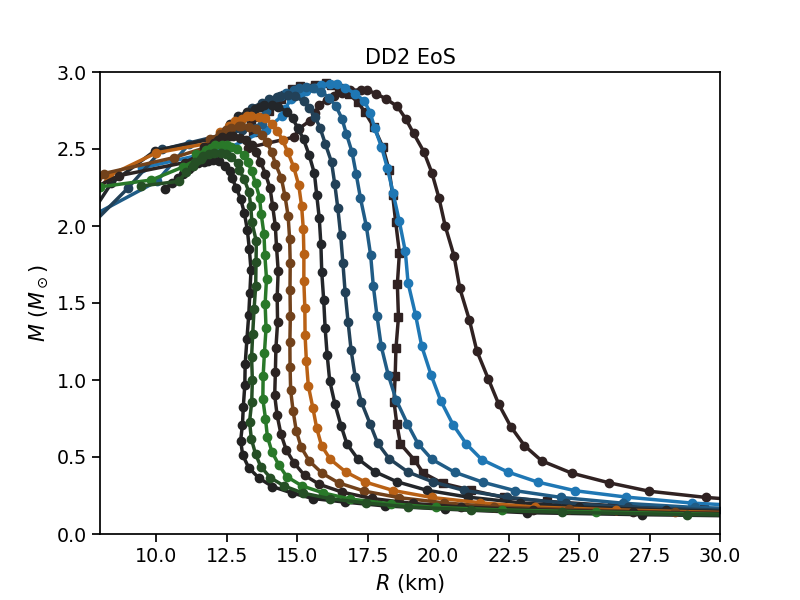

In [3]:
fig = plt.figure(figsize=(8, 6))
ax = plt.subplot(111)

# sly EoS
dd2_static_star = nn_rns_dd2.nn_rns_static
dd2_kepler_star = nn_rns_dd2.nn_rns_kepler
dd2_rotate_star = nn_rns_dd2.nn_rns_rotate

ax.plot(dd2_static_star[:,2], dd2_static_star[:,0], color=all_colors[11], marker="o", label="sly static")
ax.plot(dd2_kepler_star[:,2], dd2_kepler_star[:,0], color=all_colors[0], marker="s", label="sly kepler")

for i_ratio in range(dd2_rotate_star.shape[0]):
    ax.plot(dd2_rotate_star[i_ratio,:,2], dd2_rotate_star[i_ratio,:,0], color=all_colors[i_ratio], marker="o")

ax.set_xlim(8, 30)
ax.set_ylim(0, 3.0)

ax.set_xlabel(r"$R$ (km)")
ax.set_ylabel(r"$M$ ($M_\odot$)")
ax.set_title("DD2 EoS")

plt.show()

### 1.3 SFHo EoS

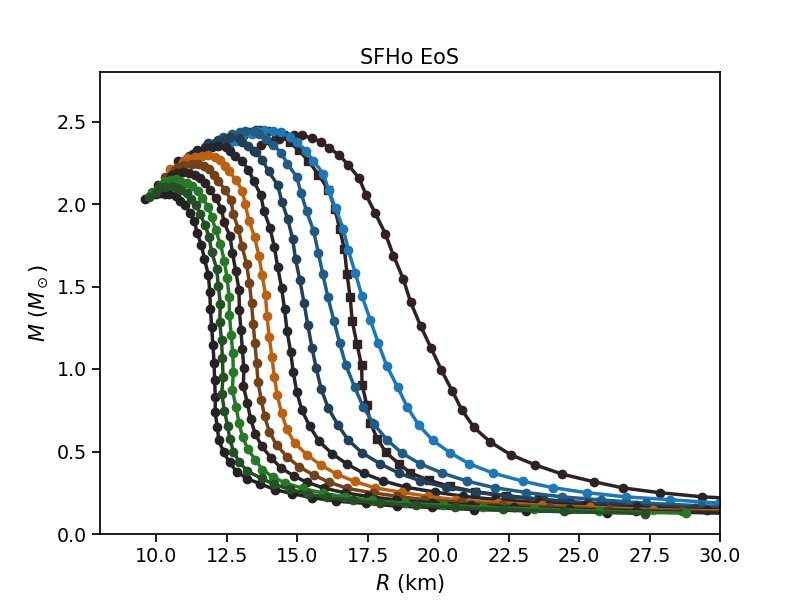

In [4]:
fig = plt.figure(figsize=(8, 6))
ax = plt.subplot(111)

# sly EoS
sfho_static_star = nn_rns_sfho.nn_rns_static
sfho_kepler_star = nn_rns_sfho.nn_rns_kepler
sfho_rotate_star = nn_rns_sfho.nn_rns_rotate

ax.plot(sfho_static_star[:,2], sfho_static_star[:,0], color=all_colors[11], marker="o", label="sly static")
ax.plot(sfho_kepler_star[:,2], sfho_kepler_star[:,0], color=all_colors[0], marker="s", label="sly kepler")

for i_ratio in range(sfho_rotate_star.shape[0]):
    ax.plot(sfho_rotate_star[i_ratio,:,2], sfho_rotate_star[i_ratio,:,0], color=all_colors[i_ratio], marker="o")

ax.set_xlim(8, 30)
ax.set_ylim(0, 2.8)

ax.set_xlabel(r"$R$ (km)")
ax.set_ylabel(r"$M$ ($M_\odot$)")
ax.set_title("SFHo EoS")

plt.show()

# 2. Interpolate observables

(1, 50, 15)


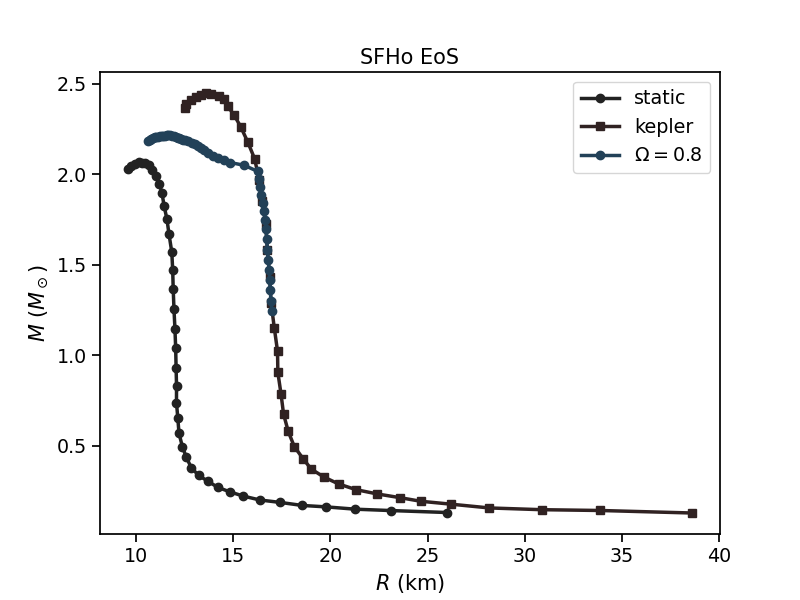

In [5]:
# compute the observables for specific Omega (r_ratio) and central energy density

ec_new = np.logspace(np.log10(7.0e14), np.log10(3.0e15), 50)
out = nn_rns_sfho.compute_observables(0.8, ec_new, rot_input_type="Omega", central_input_type="e_c")
print(out.shape)

fig = plt.figure(figsize=(8, 6))
ax = plt.subplot(111)

ax.plot(sfho_static_star[:,2], sfho_static_star[:,0], color=all_colors[11], marker="o", label="static")
ax.plot(sfho_kepler_star[:,2], sfho_kepler_star[:,0], color=all_colors[0], marker="s", label="kepler")

ax.plot(out[0,:,2], out[0,:,0], color=sat_tab0[2], marker="o", label=r"$\Omega=0.8$")

ax.set_xlabel(r"$R$ (km)")
ax.set_ylabel(r"$M$ ($M_\odot$)")
ax.set_title("SFHo EoS")

ax.legend()

plt.show()

# 3. Compute Maximum mass

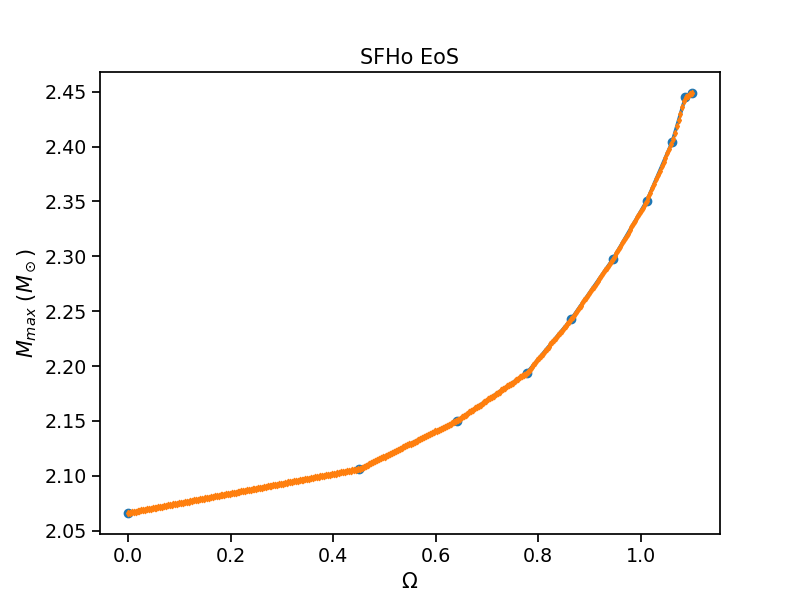

In [6]:
sfho_static_star = nn_rns_sfho.nn_rns_static
sfho_kepler_star = nn_rns_sfho.nn_rns_kepler
sfho_rotate_star = nn_rns_sfho.nn_rns_rotate

omg_arr = np.linspace(0.0, 1.0999, 300)
mmax, rrmax = nn_rns_sfho.compute_m_max(omg_arr, rot_input_type="Omega")

sorted_idx = np.argsort(nn_rns_sfho.rrmax_seq)
mask = nn_rns_sfho.rrmax_seq >= nn_rns_sfho.rrmax_seq[0]

fig = plt.figure(figsize=(8, 6))
ax = plt.subplot(111)

ax.plot(nn_rns_sfho.omgmax_seq[mask], nn_rns_sfho.mmax_seq[mask], color=sat_tab0[0], marker="o")
ax.scatter(omg_arr, mmax, color=sat_tab1[0], marker="d", s=10, zorder=5)

ax.set_xlabel(r"$\Omega$")
ax.set_ylabel(r"$M_{max}$ ($M_\odot$)")
ax.set_title("SFHo EoS")

plt.show()